In [ ]:
# mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Patient counts
Healthy: 183 unique patients
Sick: 100 unique patients
Unknown: 3 unique patients

File distribution
Patients with LESS than 20 files: 22
Patients with EXACTLY 25 files (Standard Full Set): 3
Patients with MORE than 25 files (Multiple visits/views): 255


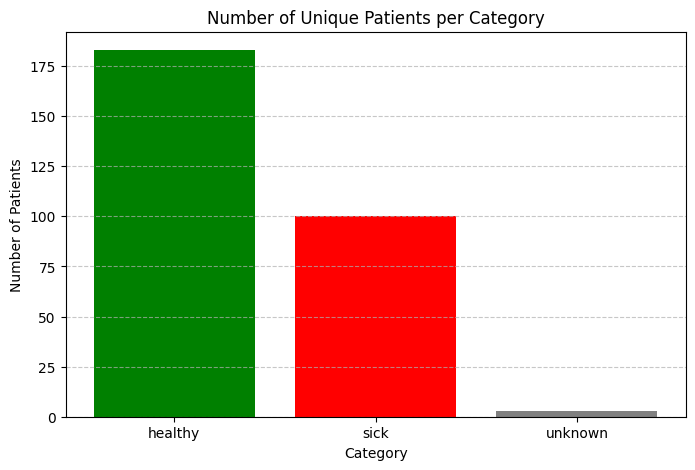

In [9]:
import os
import matplotlib.pyplot as plt

base_search = '/content/DMR-IR_dataset/DMR-IR_dataset'
categories = ['healthy', 'sick', 'unknown']

patient_counts = {}       # How many patients per category
patient_file_lengths = {} # Stores how many files each individual patient has

for category in categories:
    category_path = os.path.join(base_search, category)
    if os.path.exists(category_path):
        # get all patient IDs (which are the subfolders)
        patient_ids = [d for d in os.listdir(category_path) if os.path.isdir(os.path.join(category_path, d))]
        patient_counts[category] = len(patient_ids)

        # count files inside each patient folder
        for pid in patient_ids:
            pid_path = os.path.join(category_path, pid)
            total_files = len([f for f in os.listdir(pid_path) if os.path.isfile(os.path.join(pid_path, f))])
            patient_file_lengths[pid] = {
                'category': category,
                'file_count': total_files
            }
    else:
        patient_counts[category] = 0

# surface level summary
print("Patient counts")
for cat, count in patient_counts.items():
    print(f"{cat.capitalize()}: {count} unique patients")

# file count anomalies
# our target is 20 dynamic files per patient
less_than_20 = []
exactly_25 = []
more_than_25 = []
other_counts = {}

for pid, info in patient_file_lengths.items():
    count = info['file_count']
    if count < 20:
        less_than_20.append((pid, info['category'], count))
    elif count == 25:
        exactly_25.append(pid)
    elif count > 25:
        more_than_25.append((pid, info['category'], count))

    other_counts[count] = other_counts.get(count, 0) + 1

print("\nFile distribution")
print(f"Patients with LESS than 20 files: {len(less_than_20)}")
print(f"Patients with EXACTLY 25 files (Standard Full Set): {len(exactly_25)}")
print(f"Patients with MORE than 25 files (Multiple visits/views): {len(more_than_25)}")

# plotting patient counts
plt.figure(figsize=(8, 5))
plt.bar(patient_counts.keys(), patient_counts.values(), color=['green', 'red', 'gray'])
plt.title('Number of Unique Patients per Category')
plt.xlabel('Category')
plt.ylabel('Number of Patients')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
import os

base_search = '/content/DMR-IR_dataset/DMR-IR_dataset'
categories = ['healthy', 'sick', 'unknown']

less_than_20 = []
exactly_20 = []
more_than_20 = []

for category in categories:
    category_path = os.path.join(base_search, category)
    if os.path.exists(category_path):
        patient_ids = [d for d in os.listdir(category_path) if os.path.isdir(os.path.join(category_path, d))]

        for pid in patient_ids:
            pid_path = os.path.join(category_path, pid)
            all_files = os.listdir(pid_path)

            # catch Frontal Dynamic files regardless of Protocol (.1.1.D. OR .2.1.D.)
            frontal_dynamic_files = [
                f for f in all_files
                if (".1.1.D." in f or ".2.1.D." in f) and f.endswith('.txt')
            ]
            count = len(frontal_dynamic_files)

            if count < 20:
                less_than_20.append((pid, category, count))
            elif count == 20:
                exactly_20.append((pid, category))
            else:
                more_than_20.append((pid, category, count))

print("Frontal Dynamic Summary: ")
print(f"Patients with EXACTLY 20 files: {len(exactly_20)}")
print(f"Patients with LESS than 20 files: {len(less_than_20)}")
print(f"Patients with MORE than 20 files: {len(more_than_20)}")

if less_than_20:
    print("\nSamples that still have less than 20 frames (Incomplete Dynamic Sequences):")
    for pid, cat, count in sorted(less_than_20)[:10]: # Check the first 10
        print(f"  - Patient {pid} ({cat}): has only {count} frontal dynamic files.")

Frontal Dynamic Summary: 
Patients with EXACTLY 20 files: 232
Patients with LESS than 20 files: 30
Patients with MORE than 20 files: 24

Samples that still have less than 20 frames (Incomplete Dynamic Sequences):
  - Patient T0001 (healthy): has only 5 frontal dynamic files.
  - Patient T0002 (healthy): has only 8 frontal dynamic files.
  - Patient T0003 (healthy): has only 5 frontal dynamic files.
  - Patient T0011 (healthy): has only 0 frontal dynamic files.
  - Patient T0014 (healthy): has only 0 frontal dynamic files.
  - Patient T0018 (healthy): has only 0 frontal dynamic files.
  - Patient T0019 (healthy): has only 0 frontal dynamic files.
  - Patient T0020 (healthy): has only 0 frontal dynamic files.
  - Patient T0021 (healthy): has only 0 frontal dynamic files.
  - Patient T0022 (healthy): has only 0 frontal dynamic files.


In [13]:
import os

base_search = '/content/DMR-IR_dataset/DMR-IR_dataset'
categories = ['healthy', 'sick', 'unknown']

final_pinn_ready_sequences = []  # Stores (patient_id, category, list_of_20_files)
still_incomplete = []            # To track sets that don't hit 20 even after date filtering

for category in categories:
    category_path = os.path.join(base_search, category)
    if os.path.exists(category_path):
        patient_ids = [d for d in os.listdir(category_path) if os.path.isdir(os.path.join(category_path, d))]

        for pid in patient_ids:
            pid_path = os.path.join(category_path, pid)
            all_files = os.listdir(pid_path)

            # 1. Grab all frontal dynamic files
            frontal_files = [
                f for f in all_files
                if (".1.1.D." in f or ".2.1.D." in f) and f.endswith('.txt')
            ]

            if not frontal_files:
                continue

            # extract unique dates from these filenames
            # Filename structure split by dots: [PID, View, Subview, Type, DATE, Frame]
            dates = set()
            for f in frontal_files:
                parts = f.split('.')
                if len(parts) >= 5:
                    dates.add(parts[4]) # Extracted date string (e.g., '2019-10-23')

            # sort dates and pick the first one (upon decision made with supervisor for cases with double visits)
            sorted_dates = sorted(list(dates))
            earliest_date = sorted_dates[0]

            # filter files down to only that earliest date
            earliest_date_files = [f for f in frontal_files if earliest_date in f]

            # check if this specific date has the perfect 20 frames
            if len(earliest_date_files) == 20:
                final_pinn_ready_sequences.append((pid, category, earliest_date, earliest_date_files))
            else:
                still_incomplete.append((pid, category, len(earliest_date_files)))


print(f"Total 20-frame sequences ready for PINN: {len(final_pinn_ready_sequences)}")
print(f"Patient sets remaining incomplete/unusable: {len(still_incomplete)}")

Total 20-frame sequences ready for PINN: 251
Patient sets remaining incomplete/unusable: 18


Visualizations & Descriptive Statistics
  - Final Healthy Sequences: 158
  - Final Sick Sequences: 90
  - Final Unknown Sequences: 3

Matrix Resolution: 480 x 640 grid pixels
Temperature Range: 23.07°C to 34.78°C (Mean: 29.30°C)


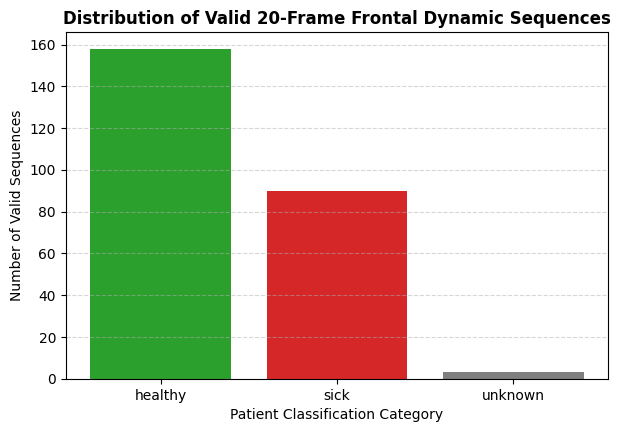

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

# count the categories of  251 clean sequences that we got from previous code block
final_counts = {'healthy': 0, 'sick': 0, 'unknown': 0}
for item in final_pinn_ready_sequences:
    category = item[1]
    final_counts[category] += 1

print("Visualizations & Descriptive Statistics")
for cat, count in final_counts.items():
    print(f"  - Final {cat.capitalize()} Sequences: {count}")

# grab one sample file from the final sequences to extract dimensions
sample_pid, sample_cat, _, sample_files = final_pinn_ready_sequences[0]
sample_path = os.path.join('/content/DMR-IR_dataset/DMR-IR_dataset', sample_cat, sample_pid, sample_files[0])

matrix = np.loadtxt(sample_path)
print(f"\nMatrix Resolution: {matrix.shape[0]} x {matrix.shape[1]} grid pixels")
print(f"Temperature Range: {np.min(matrix)}°C to {np.max(matrix)}°C (Mean: {np.mean(matrix):.2f}°C)")

# clean EDA Bar Chart
plt.figure(figsize=(7, 4.5))
plt.bar(final_counts.keys(), final_counts.values(), color=['#2ca02c', '#d62728', '#7f7f7f'])
plt.title('Distribution of Valid 20-Frame Frontal Dynamic Sequences', fontsize=12, fontweight='bold')
plt.xlabel('Patient Classification Category', fontsize=10)
plt.ylabel('Number of Valid Sequences', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

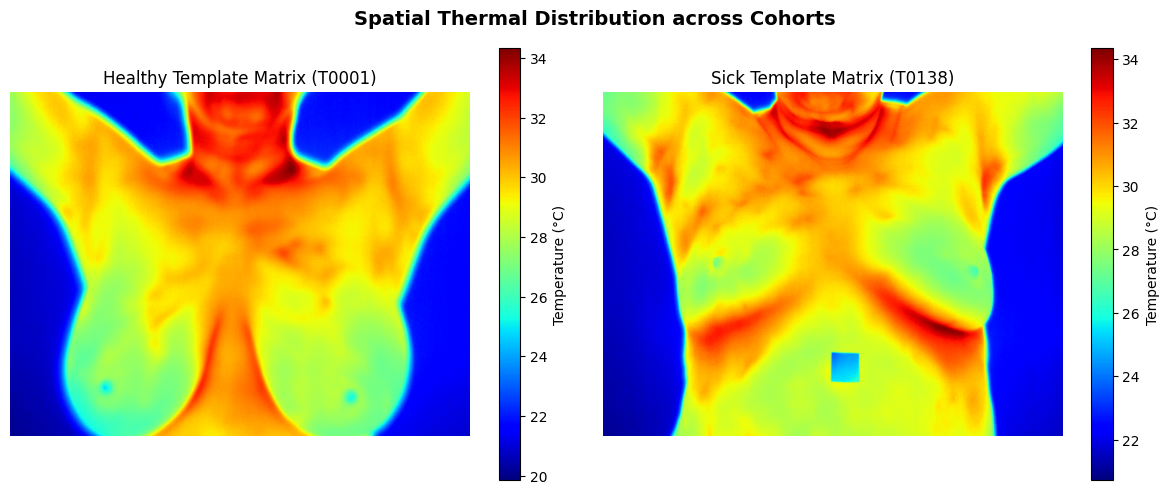

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

base_search = '/content/DMR-IR_dataset/DMR-IR_dataset'

# find the first available healthy and sick patient folders
healthy_dir = os.path.join(base_search, 'healthy')
sick_dir = os.path.join(base_search, 'sick')

healthy_pid = sorted([d for d in os.listdir(healthy_dir) if os.path.isdir(os.path.join(healthy_dir, d))])[0]
sick_pid = sorted([d for d in os.listdir(sick_dir) if os.path.isdir(os.path.join(sick_dir, d))])[0]

# locate a sample file for each
h_file = [f for f in os.listdir(os.path.join(healthy_dir, healthy_pid)) if ".D." in f][0]
s_file = [f for f in os.listdir(os.path.join(sick_dir, sick_pid)) if ".D." in f][0]

# load the 480x640 numerical matrices
healthy_matrix = np.loadtxt(os.path.join(healthy_dir, healthy_pid, h_file))
sick_matrix = np.loadtxt(os.path.join(sick_dir, sick_pid, s_file))

# plot the Heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# healthy Heatmap (using 'jet' or 'inferno' colormap for thermal look)
im1 = axes[0].imshow(healthy_matrix, cmap='jet')
axes[0].set_title(f'Healthy Template Matrix ({healthy_pid})')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], label='Temperature (°C)')

# sick Heatmap
im2 = axes[1].imshow(sick_matrix, cmap='jet')
axes[1].set_title(f'Sick Template Matrix ({sick_pid})')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], label='Temperature (°C)')

plt.suptitle('Spatial Thermal Distribution across Cohorts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
import numpy as np

# Let's look at the actual numerical matrix from the healthy sample we loaded earlier
# We'll print just a tiny 5x5 corner snippet to show the decimal temperature grid
numerical_snippet = healthy_matrix[200:205, 300:305]

print("Sample 5x5 Raw Temperature Matrix Snippet (°C)")
print(numerical_snippet)

Sample 5x5 Raw Temperature Matrix Snippet (°C)
[[30.06 30.16 30.07 30.14 30.12]
 [30.12 30.2  30.03 30.04 30.12]
 [30.11 30.05 30.11 30.03 30.1 ]
 [30.03 30.07 30.03 30.05 30.06]
 [30.02 30.07 30.07 30.06 30.13]]
